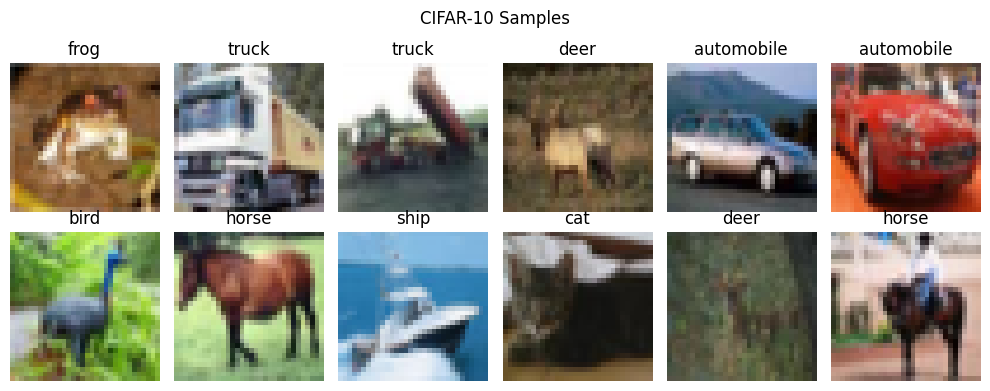

In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Load data and label names
(x_train, y_train), _ = cifar10.load_data()
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Display first 12 images
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"{label_names[y_train[i][0]]}")
    plt.axis('off')
plt.suptitle("CIFAR-10 Samples")
plt.tight_layout()
plt.show()

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# === 1. Load & Preprocess Data === #
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# === 2. Define CNN Model === #
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# === 3. Train Without Augmentation === #
model_plain = build_model()
history_plain = model_plain.fit(x_train, y_train, epochs=10, batch_size=64,
                                validation_data=(x_test, y_test), verbose=2)

# === 4. Train With Data Augmentation === #
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

model_aug = build_model()
history_aug = model_aug.fit(datagen.flow(x_train, y_train, batch_size=64),
                            epochs=10, validation_data=(x_test, y_test), verbose=2)

# === 5. Evaluate & Compare === #
loss_plain, acc_plain = model_plain.evaluate(x_test, y_test, verbose=0)
loss_aug, acc_aug = model_aug.evaluate(x_test, y_test, verbose=0)

print("\n--- Test Accuracy Comparison ---")
print(f"No Augmentation Accuracy:  {acc_plain:.4f}")
print(f"With Augmentation Accuracy:{acc_aug:.4f}")

C:\Users\Madhu\anaconda3\envs\FDS\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 - 7s - 9ms/step - accuracy: 0.4120 - loss: 1.6119 - val_accuracy: 0.5117 - val_loss: 1.3585
Epoch 2/10
782/782 - 7s - 8ms/step - accuracy: 0.5567 - loss: 1.2472 - val_accuracy: 0.5318 - val_loss: 1.2936
Epoch 3/10
782/782 - 7s - 8ms/step - accuracy: 0.6121 - loss: 1.0997 - val_accuracy: 0.5991 - val_loss: 1.1012
Epoch 4/10
782/782 - 6s - 8ms/step - accuracy: 0.6476 - loss: 1.0011 - val_accuracy: 0.6412 - val_loss: 1.0300
Epoch 5/10
782/782 - 7s - 9ms/step - accuracy: 0.6703 - loss: 0.9367 - val_accuracy: 0.6482 - val_loss: 0.9850
Epoch 6/10
782/782 - 6s - 8ms/step - accuracy: 0.6916 - loss: 0.8786 - val_accuracy: 0.6916 - val_loss: 0.8941
Epoch 7/10
782/782 - 7s - 8ms/step - accuracy: 0.7125 - loss: 0.8249 - val_accuracy: 0.6931 - val_loss: 0.8791
Epoch 8/10
782/782 - 7s - 8ms/step - accuracy: 0.7253 - loss: 0.7839 - val_accuracy: 0.7048 - val_loss: 0.8593
Epoch 9/10
782/782 - 6s - 8ms/step - accuracy: 0.7348 - loss: 0.7494 - val_accuracy: 0.6737 - val_loss: 0.9542
E

C:\Users\Madhu\anaconda3\envs\FDS\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 - 15s - 19ms/step - accuracy: 0.3772 - loss: 1.6811 - val_accuracy: 0.4890 - val_loss: 1.4026
Epoch 2/10
782/782 - 14s - 18ms/step - accuracy: 0.5059 - loss: 1.3734 - val_accuracy: 0.5725 - val_loss: 1.2171
Epoch 3/10
782/782 - 14s - 18ms/step - accuracy: 0.5544 - loss: 1.2537 - val_accuracy: 0.5896 - val_loss: 1.1661
Epoch 4/10
782/782 - 14s - 18ms/step - accuracy: 0.5795 - loss: 1.1789 - val_accuracy: 0.6312 - val_loss: 1.0465
Epoch 5/10
782/782 - 14s - 18ms/step - accuracy: 0.6014 - loss: 1.1278 - val_accuracy: 0.6405 - val_loss: 1.0351
Epoch 6/10
782/782 - 14s - 18ms/step - accuracy: 0.6184 - loss: 1.0799 - val_accuracy: 0.6425 - val_loss: 1.0276
Epoch 7/10
782/782 - 14s - 18ms/step - accuracy: 0.6297 - loss: 1.0494 - val_accuracy: 0.6526 - val_loss: 0.9908
Epoch 8/10
782/782 - 14s - 18ms/step - accuracy: 0.6435 - loss: 1.0125 - val_accuracy: 0.6329 - val_loss: 1.0642
Epoch 9/10
782/782 - 14s - 18ms/step - accuracy: 0.6518 - loss: 0.9883 - val_accuracy: 0.6618 - val_loss: 0

In [13]:
import pandas as pd
# Extract metrics from both training histories
plain_metrics = pd.DataFrame(history_plain.history)
aug_metrics = pd.DataFrame(history_aug.history)

# Combine into a single DataFrame
results = pd.DataFrame({
    "Epoch": range(1, len(plain_metrics) + 1),
    "Plain_Train_Acc": plain_metrics['accuracy'],
    "Plain_Val_Acc": plain_metrics['val_accuracy'],
    "Plain_Train_Loss": plain_metrics['loss'],
    "Plain_Val_Loss": plain_metrics['val_loss'],
    "Aug_Train_Acc": aug_metrics['accuracy'],
    "Aug_Val_Acc": aug_metrics['val_accuracy'],
    "Aug_Train_Loss": aug_metrics['loss'],
    "Aug_Val_Loss": aug_metrics['val_loss'],
})

# Display nicely rounded results
pd.set_option('display.precision', 4)
print("\n📈 Per-Epoch Comparison Table:\n")
print(results)


📈 Per-Epoch Comparison Table:

   Epoch  Plain_Train_Acc  Plain_Val_Acc  Plain_Train_Loss  Plain_Val_Loss  \
0      1           0.4120         0.5117            1.6119          1.3585   
1      2           0.5567         0.5318            1.2472          1.2936   
2      3           0.6121         0.5991            1.0997          1.1012   
3      4           0.6476         0.6412            1.0011          1.0300   
4      5           0.6703         0.6482            0.9367          0.9850   
5      6           0.6916         0.6916            0.8786          0.8941   
6      7           0.7125         0.6931            0.8249          0.8791   
7      8           0.7253         0.7048            0.7839          0.8593   
8      9           0.7348         0.6737            0.7494          0.9542   
9     10           0.7490         0.7073            0.7143          0.8627   

   Aug_Train_Acc  Aug_Val_Acc  Aug_Train_Loss  Aug_Val_Loss  
0         0.3772       0.4890          1.6811  

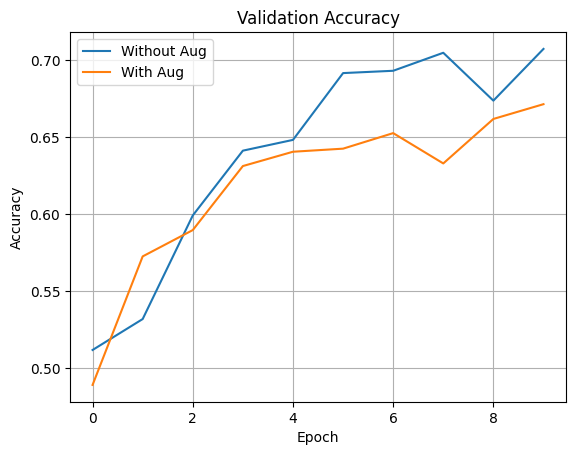

In [15]:
# === 6. Plot Accuracy Curves === #
plt.plot(history_plain.history['val_accuracy'], label='Without Aug')
plt.plot(history_aug.history['val_accuracy'], label='With Aug')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()